<a href="https://colab.research.google.com/github/Foysal348/Neural-Network-from-Scratch/blob/main/Fashion_MNIST_Classification_with_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

In [18]:
!pip install torch torchvision torchaudio
import torch ,torch.nn as nn,torch.nn.functional as F
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


## 2. Load data & visualize

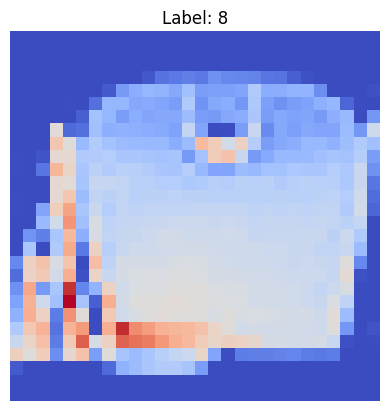

In [19]:
tfm=transforms.Compose([transforms.ToTensor()])
train=datasets.FashionMNIST('data',train=True,download=True,transform=tfm)
test=datasets.FashionMNIST('data',train=False,download=True,transform=tfm)

train_d1=DataLoader(train,batch_size=256,shuffle=True)
test_d1=DataLoader(test,batch_size=256,shuffle=False)

images, labels=next(iter(train_d1))
plt.imshow(images[0].squeeze(),cmap="coolwarm")
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

## 3. Define baseline model (logisc regression)

In [20]:
model=nn.Linear(28*28,10)
opt=torch.optim.SGD(model.parameters(),lr=0.01)


## 4. Train 5 Epochs

In [21]:
def train_epoch():
  model.train()
  loss_sum=0

  ## TRAINING
  for x,y in train_d1:
    x=x.view(x.size(0),-1)
    opt.zero_grad()
    out=model(x)
    loss=F.cross_entropy(out,y)
    loss.backward()
    opt.step()
    loss_sum +=loss.item() * x.size(0)
    return loss_sum/len(train)
for ep in range(5):
     print(f"epoch (epoch+1): loss={train_epoch():.4f}")


epoch (epoch+1): loss=0.0100
epoch (epoch+1): loss=0.0098
epoch (epoch+1): loss=0.0098
epoch (epoch+1): loss=0.0096
epoch (epoch+1): loss=0.0095


## 5. Evaluation

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix
model.eval()
preds,targs=[],[]
with torch.no_grad():
  for x,y in test_d1:
    p=model(x.view(x.size(0),-1)).argmax(1)
    preds +=p.tolist()
    targs += y.tolist()
print("Accuracy:",accuracy_score(targs,preds))
print(f"Confusion Matrix:\n{confusion_matrix(targs,preds)}")


Accuracy: 0.2027
Confusion Matrix:
[[846  14   1   7  31   5  66   2   6  22]
 [292  17   0 659  19   1  10   0   0   2]
 [293  68 101  22 199  15 279   0   2  21]
 [748  38   2  21 106   1  75   0   3   6]
 [417  52 126  40 168  17 162   1   1  16]
 [ 17 246  76  20  99  95 229  22  27 169]
 [516  57  71  46 103  10 160   0   5  32]
 [  0 732   5   1   7  11  43   4   7 190]
 [ 93 117  92  63  27  77 164   1 253 113]
 [  5  88  32   2   9   3 432   0  67 362]]


##6.SHOW MISCLASSIFIED

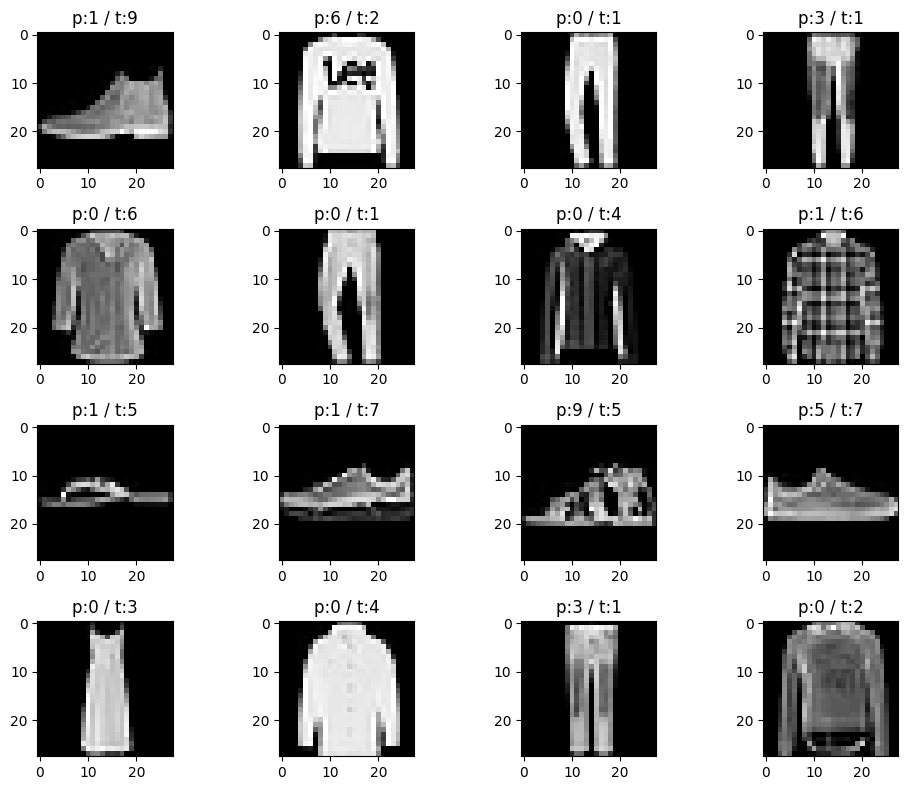

In [26]:
wrong=[i for i,(p,t) in enumerate(zip(preds,targs)) if p!=t][:16]
grid =plt.figure(figsize=(10,8))
for j,i in enumerate(wrong):
  ax=grid.add_subplot(4,4,j+1)
  img,_=test[i]
  ax.imshow(img.squeeze(),cmap='gray')
  ax.set_title(f"p:{preds[i]} / t:{targs[i]}")
plt.tight_layout()
plt.show()